In [10]:
from THM_main import Version5_THM_prototype
from iapws import IAPWS97
import numpy as np
from THM_main import plotting
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
# Begining of the script used to test the THM prototype class.

In [11]:
def guess_power_density_sine(Ptot, h, r, num_control_volumes): # New version, supposed to be more accurate but introduced alot of instability in the TH solution
    """
    Compute the power density in a cylinder with a sine-shaped profile along the axial direction.

    Parameters:
    Ptot (float): Total power released in the cylinder [W].
    h (float): Total height of the cylinder [m].
    r (float): Radius of the cylinder [m].
    num_control_volumes (int): Number of control volumes along the z-axis.

    Returns:
    z_values (numpy array): Array of z positions (center of each control volume) along the height of the cylinder.
    power_density (numpy array): Array of power densities corresponding to each control volume.
    q0 (float): The peak power density constant.
    """
    
    # Cross-sectional area of the cylinder
    A_cross_section = np.pi * r**2

    # Function for the power density profile along the axial direction
    def q(z, q0):
        return q0 * np.sin(np.pi * z / h)

    # Calculate q0 to ensure total power matches Ptot
    q0 = Ptot / (A_cross_section * (2 * h / np.pi))  # derived from the integral

    # Compute the boundaries and midpoints of each control volume
    z_boundaries = np.linspace(0, h, num_control_volumes + 1)
    z_values = (z_boundaries[:-1] + z_boundaries[1:]) / 2  # Midpoints of control volumes

    # Compute power density at each midpoint
    power_density = q(z_values, q0)

    return z_values, power_density

In [12]:
compute_case_monophasic = True
if compute_case_monophasic:
    case_name = "genfoam_comparaison_correl"
    #User choice:
    solveConduction = False
    zPlotting = [0.8]

 ########## Thermal hydraulics parameters ##########
    ## Geometric parameters
    canalType = "square" # "square", "cylindrical"
    waterRadius = 1.296e-2 #1.295e-2 # m : ATRIUM10 pincell pitch   0.0126 #
    fuelRadius = 0.4435e-2 # m : fuel rod radius
    gapRadius = 0.4520e-2 # m : expansion gap radius : "void" between fuel and clad - equivalent to inner clad radius
    cladRadius = 0.5140e-2 # m : clad external radius
    height = 1.555 # m : height : active core height in BWRX-300 SMR

    ## Fluid parameters
    tInlet = 270 + 273.15 # K, for BWRX-300 SMR core
    #Nominal operating pressure = 7.2 MPa (abs)
    pOutlet =  7.2e6 # Pa 
    flowArea = waterRadius ** 2 - np.pi * cladRadius ** 2
    massFlowRate = 1530  / (200*91)  # kg/s

    ## Meshing parameters:
    If = 8
    I1 = 3
    Iz1 = 70 # number of control volumes in the axial direction

    ## Thermalhydraulics correlation
    voidFractionCorrel = "EPRIvoidModel"    #choice between 'EPRIvoidModel' and 'GEramp' and 'modBestion' and 'HEM1'
    frfaccorel = "Churchill"                #choice between 'Churchill' and 'blasius'
    P2Pcorel = "MNmodel"                   z    #choice between 'HEM1' and 'HEM2' and 'MNmodel'
    numericalMethod = 'BiCG'            #choice between 'BiCG', 'BiCGStab', 'GaussSiedel' and 'FVM'

    ############ Nuclear Parameters ###########
    ## Fission parameters
    qFiss = 19433012
    #qFiss = 1943301220 # W/m3
    ## Material parameters
    kFuel = 4.18 # W/m.K, TECHNICAL REPORTS SERIES No. 59 : Thermal Conductivity of Uranium Dioxide, IAEA, VIENNA, 1966
    Hgap = 10000
    kClad = 21.5 # W/m.K, Thermal Conductivity of Zircaloy-2 (as used in BWRX-300) according to https://www.matweb.com/search/datasheet.aspx?MatGUID=eb1dad5ce1ad4a1f9e92f86d5b44740d
    # k_Zircaloy-4 = 21.6 W/m.K too so check for ATRIUM-10 clad material but should have the same thermal conductivity
    ########## Algorithm parameters ###########
    nIter = 1000
    tol = 1e-4

    """Qfiss1 = [
    2.573626970467444956e+08, 4.623305024389328957e+08, 6.407967268034104109e+08,
    7.990585028044009209e+08, 9.368766574531430006e+08, 1.049998322399374366e+09,
    1.128397084940406799e+09, 1.135655778390735626e+09, 1.094743013229360342e+09,
    1.043515262638570189e+09, 9.939179257216792107e+08, 9.458008913037365675e+08,
    9.018682058875366449e+08, 8.614284509984154701e+08, 8.233966998979817629e+08,
    7.868846465870770216e+08, 7.527352435700626373e+08, 7.205178994315886497e+08,
    6.899423518049228191e+08, 6.608178492266358137e+08, 6.330116215639107227e+08,
    6.064302050460877419e+08, 5.810297579615226984e+08, 5.567133483311305046e+08,
    5.334865786454480290e+08, 5.106867543098468184e+08, 4.889343289188963175e+08,
    4.681194758724330068e+08, 4.481648274440382719e+08, 4.290049323157238960e+08,
    4.105908798558350205e+08, 3.928819853116885424e+08, 3.758423660653365254e+08,
    3.594398744925226569e+08, 3.436444972511007190e+08, 3.284283997452365756e+08,
    3.137650368412132263e+08, 2.996294418847844601e+08, 2.859974708095957041e+08,
    2.728462023150924444e+08, 2.601537377775578499e+08, 2.478986899116983116e+08,
    2.360606718769596517e+08, 2.246201194206790030e+08, 2.135579573965168893e+08,
    2.028559999423420131e+08, 1.924969949444426298e+08, 1.824657578749053776e+08,
    1.727430134984386861e+08, 1.633125212621246874e+08, 1.541595968604162037e+08,
    1.452897649714789689e+08, 1.366343839702166617e+08, 1.282021021455848813e+08,
    1.199802694296749830e+08, 1.119558133445722610e+08, 1.041155947160474956e+08,
    9.644685231566146016e+07, 8.893594674681581557e+07, 8.157039468238835037e+07,
    7.433734596551620960e+07, 6.722385039486764371e+07, 6.021652424305437505e+07,
    5.330097222189800441e+07, 4.646078703769098222e+07, 3.967568745237813145e+07,
    3.291816123565715179e+07, 2.614726796562767401e+07, 1.929737429893992841e+07,
    1.225730720356012881e+07] """
    
    Qfiss1 = [qFiss for i in range(Iz1)]

    """ Qfiss1 = []
    for i in range(Iz1-5): 
        if i*(height/Iz1) < 0.1:
            Qfiss1.append(0)
        else:
            Qfiss1.append(1943301220)
            #Qfiss1.append(p[i-5])
    Qfiss1.append(0)
    Qfiss1.append(0)
    Qfiss1.append(0)
    Qfiss1.append(0)
    Qfiss1.append(0)
    print(Qfiss1) """

    case0 = Version5_THM_prototype("Initialization of BWR Pincell equivalent canal", canalType, waterRadius, fuelRadius, gapRadius, cladRadius, 
                            height, tInlet, pOutlet, massFlowRate, Qfiss1, kFuel, Hgap, kClad, Iz1, If, I1, zPlotting, 
                            solveConduction, dt = 0, t_tot = 0, frfaccorel = frfaccorel, P2Pcorel = P2Pcorel, voidFractionCorrel = voidFractionCorrel, 
                            numericalMethod = numericalMethod)
    

$$$---------- THM: prototype, case treated : Initialization of BWR Pincell equivalent canal.
$$$---------- THM: prototype, steady state case.
$$---------- Calling DFM class.
Setting up heat convection solution along the axial dimension. zmax = 1.655 m with 70 axial elements.
self.I_z: 70
self.qFlow: 0.01914916867442876
self.pOutlet: 14739394.95
self.Lf: 1.655
self.r_f: 0.0056
self.clad_r: 0.00652
self.r_w: 0.01296
self.Dz: 0.023642857142857143
self.dt: 0
Courant number: 0.0
Numerical Method BiCG
Velocity at the inlet:  0.8578588063766596
Hydraulic diameter: [0.0033599502390329375, 0.0033599502390329375, 0.0033599502390329375, 0.0033599502390329375, 0.0033599502390329375, 0.0033599502390329375, 0.0033599502390329375, 0.0033599502390329375, 0.0033599502390329375, 0.0033599502390329375, 0.0033599502390329375, 0.0033599502390329375, 0.0033599502390329375, 0.0033599502390329375, 0.0033599502390329375, 0.0033599502390329375, 0.0033599502390329375, 0.0033599502390329375, 0.0033599502390329375

KeyboardInterrupt: 

In [ ]:
class GFPlotter():
    def __init__(self, caseList, directory_path, case_name):
        self.case_name = f'{case_name}\\'

        self.caseList = caseList
        self.directory_path = directory_path
        self.height = self.caseList[0].convection_sol.height

        self.data_dict_list = []
        self.data_dict = self.read_files_in_directory()
        self.allow_space()

        self.struture_fraction = 1 - (self.alpha_liquid[0] + self.alpha_vapour[0])

        self.calculateFields()
        self.createZ()

    def plotCase(self):
        title = f"f: {self.caseList[0].convection_sol.frfaccorel}, \n Méthode numérique: {self.caseList[0].convection_sol.numericalMethod}, \n Correlation void fraction: {self.caseList[0].convection_sol.voidFractionCorrel}"
        labelTitle = 'DFM'
        fig1, ax1 = plt.subplots()
        for i in range(len(self.caseList)):
            ax1.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.T_water, label=labelTitle)
        ax1.set_xlabel("Axial position in m")
        ax1.set_ylabel("Temperature in K")
        ax1.set_title(f"{title}")
        ax1.grid()
        ax1.legend(loc="best")
        fig1.savefig(rf'result\{self.case_name}\Tcoolant.png', bbox_inches='tight')

        fig2, ax2 = plt.subplots()
        for i in range(len(self.caseList)):
            ax2.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.voidFraction[-1], label=labelTitle)

        ax2.set_xlabel("Axial position in m")
        ax2.set_ylabel("Void fraction")
        ax2.set_title(f"{title}")
        ax2.grid()
        ax2.legend(loc="best")
        fig2.savefig(rf'result\{self.case_name}\epsilon.png', bbox_inches='tight')

        fig3, ax3 = plt.subplots()
        print(f"rho_mix: {self.rho_mixture}")
        for i in range(len(self.caseList)):
            ax3.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rho[-1], label=labelTitle)

        ax3.set_xlabel("Axial position in m")
        ax3.set_ylabel("Density in kg/m^3")
        ax3.set_title(f"{title}")
        ax3.grid()
        ax3.legend(loc="best")
        fig3.savefig(rf'result\{self.case_name}\Rho.png', bbox_inches='tight')

        fig7, ax7 = plt.subplots()
        for i in range(len(self.caseList)):
            ax7.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rhoL[-1], label=labelTitle)
        ax7.set_xlabel("Axial position in m")
        ax7.set_ylabel("Liquid density in kg/m^3")
        ax7.set_title(f"{title}")
        ax7.grid()
        ax7.legend(loc="best")
        fig7.savefig(rf'result\{self.case_name}\RhoL.png', bbox_inches='tight')

        fig8, ax8 = plt.subplots()
        for i in range(len(self.caseList)):
            ax8.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rhoG[-1], label=labelTitle)
        ax8.set_xlabel("Axial position in m")
        ax8.set_ylabel("Vapour density in kg/m^3")
        ax8.set_title(f"{title}")
        ax8.grid()
        ax8.legend(loc="best")
        fig8.savefig(rf'result\{self.case_name}\RhoG.png', bbox_inches='tight')

        fig4, ax4 = plt.subplots() 
        for i in range(len(self.caseList)):
            ax4.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.P[-1], label=labelTitle)
        ax4.step(self.zList, self.p_rgh, label="GenFoam P_rgh")
        ax4.set_xlabel("Axial position in m")
        ax4.set_ylabel("Pressure in Pa")
        ax4.grid()
        ax4.set_title(f"{title}")
        ax4.legend(loc="best")
        fig4.savefig(rf'result\{self.case_name}\P.png', bbox_inches='tight')

        fig5, ax5 = plt.subplots()
        for i in range(len(self.caseList)):
            ax5.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ul, label=labelTitle)
        ax5.set_xlabel("Axial position in m")
        ax5.set_ylabel("Liquid Velocity in m/s")
        ax5.set_title(f"{title}")
        ax5.grid()
        ax5.legend(loc="best")
        fig5.savefig(rf'result\{self.case_name}\Ul.png', bbox_inches='tight')

        fig6, ax6 = plt.subplots()
        for i in range(len(self.caseList)):
            ax6.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ug, label=labelTitle)
        ax6.set_xlabel("Axial position in m")
        ax6.set_ylabel("Vapour Velocity in m/s")
        ax6.set_title(f"{title}")
        ax6.grid()
        ax6.legend(loc="best")
        fig6.savefig(rf'result\{self.case_name}\Ug.png', bbox_inches='tight')

        fig9, ax9 = plt.subplots()
        for i in range(len(self.caseList)):
            ax9.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.U[-1], label=labelTitle)
        ax9.set_xlabel("Axial position in m")
        ax9.set_ylabel("Mixture Velocity in m/s")
        ax9.set_title(f"{title}")
        ax9.grid()
        ax9.legend(loc="best")
        fig9.savefig(rf'result\{self.case_name}\U.png', bbox_inches='tight')

        fig10, ax10 = plt.subplots()
        for i in range(len(self.caseList)):
            ax10.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Rel, label=labelTitle)
        ax10.set_xlabel("Axial position in m")
        ax10.set_ylabel("Reynolds number")
        ax10.set_title(f"{title}")
        ax10.grid()
        ax10.legend(loc="best")
        fig10.savefig(rf'result\{self.case_name}\Re.png', bbox_inches='tight')

        fig11, ax11 = plt.subplots()
        ax11.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.xTh[-1], label=labelTitle)
        ax11.set_xlabel("Axial position in m")
        ax11.set_ylabel("xTh")
        ax11.set_title(f"{title}")
        ax11.grid()
        ax11.legend(loc="best")
        fig11.savefig(rf'result\{self.case_name}\xTh.png', bbox_inches='tight')

        
        fig12, ax12 = plt.subplots()
        for i in range(len(self.caseList)):
            rhoUA_liquid = [self.caseList[i].convection_sol.Ul[j] * self.caseList[i].convection_sol.rhoL[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ul))]
            ax12.step(self.caseList[i].convection_sol.z_mesh, rhoUA_liquid, label=labelTitle + " rhoUA_liquid")
        #ax12.step(self.zList, self.alphaRhoMagU_liquid, label="GenFoam")
        ax12.set_xlabel("Axial position in m")
        ax12.set_ylabel("rhoUA_liquid")
        ax12.set_title(f"{title}")
        ax12.grid()
        fig12.savefig(rf'result\{self.case_name}\rhoUA_liquid.png', bbox_inches='tight')

        fig13, ax13 = plt.subplots()
        for i in range(len(self.caseList)):
            rhoUA_vapour = [self.caseList[i].convection_sol.Ug[j] * self.caseList[i].convection_sol.rhoG[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ug))]
            ax13.step(self.caseList[i].convection_sol.z_mesh, rhoUA_vapour, label=labelTitle + " rhoUA_vapour")
        #ax13.step(self.zList, self.alphaRhoMagU_vapour, label="GenFoam")
        ax13.set_xlabel("Axial position in m")
        ax13.set_ylabel("rhoUA_vapour")
        ax13.set_title(f"{title}")
        ax13.grid()
        fig13.savefig(rf'result\{self.case_name}\rhoUA_vapour.png', bbox_inches='tight')

        fig14, ax14 = plt.subplots()
        for i in range(len(self.caseList)):
            self.rhoUA = [self.caseList[i].convection_sol.U[-1][j] * self.caseList[i].convection_sol.rho[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ug))]
            ax14.step(self.caseList[i].convection_sol.z_mesh, self.rhoUA, label=labelTitle + " rhoUA")
        #ax14.step(self.zList, self.alphaRhoMagU_liquid, label="GenFoam")
        ax14.set_xlabel("Axial position in m")
        ax14.set_ylabel("rhoUA")
        ax14.set_title(f"{title}")
        ax14.grid()
        fig14.savefig(rf'result\{self.case_name}\rhoUA.png', bbox_inches='tight')
        

        plt.show()

    def createZ(self):
        self.zList = np.linspace(0, self.height, len(self.alpha_liquid))

    def read_files_in_directory(self):
        data_dict = {}
        print(f"Reading files in directory: {self.directory_path}")
        # Parcourt tous les fichiers du dossier
        for filename in os.listdir(self.directory_path):
            file_path = os.path.join(self.directory_path, filename)
            print(f"Reading file: {file_path}")
            # Vérifie que c'est bien un fichier
            if os.path.isfile(file_path):

                with open(file_path, 'r') as file:
                    content = file.read()
                    
                    # Trouve la première parenthèse ouvrante et fermante
                    start = content.find('(')
                    end = content.find(')', start)
                    #end = start + 74
                    if start != -1 and end != -1:
                        # Extrait les données entre les parenthèses
                        data_str = content[start+1:end].strip()
                        # Divise les lignes en liste de chaînes
                        data_lines = data_str.splitlines()
                        if len(data_lines) != 1:
                            print(f'data_lines: {data_lines}')
                            float_list = [float(item) for item in data_lines]
                            data_dict[filename] = float_list

                    if len(data_lines) == 1:
                        # Trouve la première parenthèse ouvrante et fermante
                        start = content.find('(')
                        end = content.find(';', start)
                        #end = start
                        if start != -1 and end != -1:
                            # Extrait les données entre les parenthèses
                            data_str = content[start+1:end].strip()
                            # Divise les lignes en liste de chaînes
                            data_lines = data_str.splitlines()
                            data_lines.pop()
                            print(data_lines)
                            x, y, z = np.zeros(len(data_lines)), np.zeros(len(data_lines)), np.zeros(len(data_lines))
                            for i in range(len(data_lines)):
                                a = values = data_lines[i].strip("()").split()
                                x[i] = float(a[0])
                                y[i] = float(a[1])
                                z[i] = float(a[2])
                            data_dict[fr'{filename}_x'] = x
                            data_dict[fr'{filename}_y'] = y
                            data_dict[fr'{filename}_z'] = z
        
        return data_dict
    
    def allow_space(self):
        self.alpha_liquid = np.array(self.data_dict['alpha.liquid'])
        self.alpha_vapour = np.array(self.data_dict['alpha.vapour'])
        #self.alpha_powerModel = np.array(self.data_dict['alpha.powerModel'])
        self.alphaPhi_liquid = np.array(self.data_dict['alphaPhi.liquid']+ [self.data_dict['alphaPhi.liquid'][-1]])
        self.alphaPhi_vapour = np.array(self.data_dict['alphaPhi.vapour']+ [self.data_dict['alphaPhi.vapour'][-1]])
        self.alphaRhoMagU_liquid = np.array(self.data_dict['alphaRhoMagU.liquid'])#+ [self.data_dict['alphaRhoMagU.liquid'][-1]])
        self.alphaRhoMagU_vapour = np.array(self.data_dict['alphaRhoMagU.vapour'])#+ [self.data_dict['alphaRhoMagU.vapour'][-1]])
        self.alphaRhoPhi_liquid = np.array(self.data_dict['alphaRhoPhi.liquid']+ [self.data_dict['alphaRhoPhi.liquid'][-1]])
        self.alphaRhoPhi_vapour = np.array(self.data_dict['alphaRhoPhi.vapour']+ [self.data_dict['alphaRhoPhi.vapour'][-1]])
        self.areaDensity_interface = np.array(self.data_dict['areaDensity.interface'])
        self.dgdt_liquid = np.array(self.data_dict['dgdt.liquid'])
        self.dgdt_vapour = np.array(self.data_dict['dgdt.vapour'])
        self.dmdt_vapour = np.array(self.data_dict['dmdt.liquid.vapour'])
        self.heatFlux_structure = np.array(self.data_dict['heatFlux.structure'])
        self.htc_liquid_interface = np.array(self.data_dict['htc.liquid.interface'])
        self.htc_liquid_structure = np.array(self.data_dict['htc.liquid.structure'])
        self.p = np.array(self.data_dict['p'])
        self.p_rgh = np.array(self.data_dict['p_rgh'])
        self.Re_liquid_structure = np.array(self.data_dict['Re.liquid.structure'])
        self.Re_vapour_structure = np.array(self.data_dict['Re.vapour.structure'])
        self.Re_liquid_vapour = np.array(self.data_dict['Re.liquid.vapour'])
        self.T_fixedPower = np.array(self.data_dict['T.fixedPower'])
        self.T_liquid = np.array(self.data_dict['T.liquid'])
        self.T_vapour = np.array(self.data_dict['T.vapour'])
        self.U_liquid_x = np.array(self.data_dict['U.liquid_x'])
        self.U_liquid_y = np.array(self.data_dict['U.liquid_y'])
        self.U_liquid_z = np.array(self.data_dict['U.liquid_z'])
        self.U_vapour_x = np.array(self.data_dict['U.vapour_x'])
        self.U_vapour_y = np.array(self.data_dict['U.vapour_y'])
        self.U_vapour_z = np.array(self.data_dict['U.vapour_z'])

    def calculateFields(self):
        self.alpha_vapour = self.alpha_vapour/(1-self.struture_fraction)
        self.alpha_liquid = self.alpha_liquid/(1-self.struture_fraction)
        self.U_liquid = np.sqrt(self.U_liquid_x**2 + self.U_liquid_y**2 + self.U_liquid_z**2)
        self.U_vapour = np.sqrt(self.U_vapour_x**2 + self.U_vapour_y**2 + self.U_vapour_z**2)
        self.U_mixture = (1-self.alpha_vapour) * self.U_liquid + self.alpha_vapour * self.U_vapour

        self.rho_liquid  = self.alphaRhoPhi_liquid/(self.alphaPhi_liquid)
        self.rho_vapour = self.alphaRhoPhi_vapour/(self.alphaPhi_vapour)
        for i in range(len(self.rho_vapour)):
            if np.isnan(self.rho_vapour[i]):
                self.rho_vapour[i] = 0
            if np.isnan(self.rho_liquid[i]):
                self.rho_liquid[i] = 0
        print(f"rho_liquid: {self.rho_liquid}")
        print(f"rho_vapour: {self.rho_vapour}")
        self.rho_mixture = self.rho_liquid + self.rho_vapour

        self.T_mixture = (1-self.alpha_vapour) * self.T_liquid + self.alpha_vapour * self.T_vapour

    def plotComparison(self):
        file_path = rf'C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\result\{self.case_name}'
        os.makedirs(os.path.dirname(file_path), exist_ok=True)
        if len(self.caseList) == 1:
            labelTitle = 'DFM'
        title = f"f: {self.caseList[0].convection_sol.frfaccorel}, \n Méthode numérique: {self.caseList[0].convection_sol.numericalMethod}, \n Correlation void fraction: {self.caseList[0].convection_sol.voidFractionCorrel}"
        fig1, ax1 = plt.subplots()
        for i in range(len(self.caseList)):
            ax1.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.T_water, label=labelTitle)
        ax1.step(self.zList, self.T_liquid, label="GenFoam T.liquid")
        ax1.step(self.zList, self.T_vapour, label="GenFoam T.vapour")
        ax1.step(self.zList, self.T_mixture, label="GenFoam T.mixture")
        ax1.set_xlabel("Axial position in m")
        ax1.set_ylabel("Temperature in K")
        ax1.set_title(f"{title}")
        ax1.grid()
        ax1.legend(loc="best")
        fig1.savefig(rf'result\{self.case_name}\Tcoolant.png', bbox_inches='tight')

        fig2, ax2 = plt.subplots()
        for i in range(len(self.caseList)):
            ax2.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.voidFraction[-1], label=labelTitle)
        ax2.step(self.zList, self.alpha_vapour, label="GenFoam")
        ax2.set_xlabel("Axial position in m")
        ax2.set_ylabel("Void fraction")
        ax2.set_title(f"{title}")
        ax2.grid()
        ax2.legend(loc="best")
        fig2.savefig(rf'result\{self.case_name}\epsilon.png', bbox_inches='tight')

        fig3, ax3 = plt.subplots()
        print(f"rho_mix: {self.rho_mixture}")
        for i in range(len(self.caseList)):
            ax3.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rho[-1], label=labelTitle)
        ax3.plot(self.zList, self.rho_mixture, label="GenFoam")
        ax3.set_xlabel("Axial position in m")
        ax3.set_ylabel("Density in kg/m^3")
        ax3.set_title(f"{title}")
        ax3.grid()
        ax3.legend(loc="best")
        fig3.savefig(rf'result\{self.case_name}\Rho.png', bbox_inches='tight')

        fig7, ax7 = plt.subplots()
        for i in range(len(self.caseList)):
            ax7.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rhoL[-1], label=labelTitle)
        ax7.plot(self.zList, self.rho_liquid, label="GenFoam")
        ax7.set_xlabel("Axial position in m")
        ax7.set_ylabel("Liquid density in kg/m^3")
        ax7.set_title(f"{title}")
        ax7.grid()
        ax7.legend(loc="best")
        fig7.savefig(rf'result\{self.case_name}\RhoL.png', bbox_inches='tight')

        fig8, ax8 = plt.subplots()
        for i in range(len(self.caseList)):
            ax8.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.rhoG[-1], label=labelTitle)
        ax8.plot(self.zList, self.rho_vapour, label="GenFoam")
        ax8.set_xlabel("Axial position in m")
        ax8.set_ylabel("Vapour density in kg/m^3")
        ax8.set_title(f"{title}")
        ax8.grid()
        ax8.legend(loc="best")
        fig8.savefig(rf'result\{self.case_name}\RhoG.png', bbox_inches='tight')

        fig4, ax4 = plt.subplots() 
        for i in range(len(self.caseList)):
            ax4.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.P[-1], label=labelTitle)
        ax4.step(self.zList, self.p, label="GenFoam")
        ax4.step(self.zList, self.p_rgh, label="GenFoam P_rgh")
        ax4.set_xlabel("Axial position in m")
        ax4.set_ylabel("Pressure in Pa")
        ax4.grid()
        ax4.set_title(f"{title}")
        ax4.legend(loc="best")
        fig4.savefig(rf'result\{self.case_name}\P.png', bbox_inches='tight')

        fig5, ax5 = plt.subplots()
        for i in range(len(self.caseList)):
            ax5.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ul, label=labelTitle)
        ax5.step(self.zList, self.U_liquid, label="GenFoam")
        ax5.set_xlabel("Axial position in m")
        ax5.set_ylabel("Liquid Velocity in m/s")
        ax5.set_title(f"{title}")
        ax5.grid()
        ax5.legend(loc="best")
        fig5.savefig(rf'result\{self.case_name}\Ul.png', bbox_inches='tight')

        fig6, ax6 = plt.subplots()
        for i in range(len(self.caseList)):
            ax6.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Ug, label=labelTitle)
        ax6.step(self.zList, self.U_vapour, label="GenFoam")
        ax6.set_xlabel("Axial position in m")
        ax6.set_ylabel("Vapour Velocity in m/s")
        ax6.set_title(f"{title}")
        ax6.grid()
        ax6.legend(loc="best")
        fig6.savefig(rf'result\{self.case_name}\Ug.png', bbox_inches='tight')

        fig9, ax9 = plt.subplots()
        for i in range(len(self.caseList)):
            ax9.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.U[-1], label=labelTitle)
        ax9.step(self.zList, self.U_mixture, label="GenFoam")
        ax9.set_xlabel("Axial position in m")
        ax9.set_ylabel("Mixture Velocity in m/s")
        ax9.set_title(f"{title}")
        ax9.grid()
        ax9.legend(loc="best")
        fig9.savefig(rf'result\{self.case_name}\U.png', bbox_inches='tight')

        fig10, ax10 = plt.subplots()
        for i in range(len(self.caseList)):
            ax10.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.Rel, label=labelTitle)
        ax10.step(self.zList, self.Re_liquid_structure, label="GenFoam")
        ax10.set_xlabel("Axial position in m")
        ax10.set_ylabel("Reynolds number")
        ax10.set_title(f"{title}")
        ax10.grid()
        ax10.legend(loc="best")
        fig10.savefig(rf'result\{self.case_name}\Re.png', bbox_inches='tight')

        fig11, ax11 = plt.subplots()
        ax11.step(self.caseList[i].convection_sol.z_mesh, self.caseList[i].convection_sol.xTh[-1], label=labelTitle)
        ax11.set_xlabel("Axial position in m")
        ax11.set_ylabel("xTh")
        ax11.set_title(f"{title}")
        ax11.grid()
        ax11.legend(loc="best")
        fig11.savefig(rf'result\{self.case_name}\xTh.png', bbox_inches='tight')

        
        fig12, ax12 = plt.subplots()
        for i in range(len(self.caseList)):
            rhoUA_liquid = [self.caseList[i].convection_sol.Ul[j] * self.caseList[i].convection_sol.rhoL[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ul))]
            ax12.step(self.caseList[i].convection_sol.z_mesh, rhoUA_liquid, label=labelTitle + " rhoUA_liquid")
        #ax12.step(self.zList, self.alphaRhoMagU_liquid, label="GenFoam")
        ax12.set_xlabel("Axial position in m")
        ax12.set_ylabel("rhoUA_liquid")
        ax12.set_title(f"{title}")
        ax12.grid()
        fig12.savefig(rf'result\{self.case_name}\rhoUA_liquid.png', bbox_inches='tight')

        fig13, ax13 = plt.subplots()
        for i in range(len(self.caseList)):
            rhoUA_vapour = [self.caseList[i].convection_sol.Ug[j] * self.caseList[i].convection_sol.rhoG[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ug))]
            ax13.step(self.caseList[i].convection_sol.z_mesh, rhoUA_vapour, label=labelTitle + " rhoUA_vapour")
        #ax13.step(self.zList, self.alphaRhoMagU_vapour, label="GenFoam")
        ax13.set_xlabel("Axial position in m")
        ax13.set_ylabel("rhoUA_vapour")
        ax13.set_title(f"{title}")
        ax13.grid()
        fig13.savefig(rf'result\{self.case_name}\rhoUA_vapour.png', bbox_inches='tight')

        fig14, ax14 = plt.subplots()
        for i in range(len(self.caseList)):
            self.rhoUA = [self.caseList[i].convection_sol.U[-1][j] * self.caseList[i].convection_sol.rho[-1][j]*self.caseList[i].convection_sol.areaMatrix[j] for j in range(len(self.caseList[i].convection_sol.Ug))]
            ax14.step(self.caseList[i].convection_sol.z_mesh, self.rhoUA, label=labelTitle + " rhoUA")
        #ax14.step(self.zList, self.alphaRhoMagU_liquid, label="GenFoam")
        ax14.set_xlabel("Axial position in m")
        ax14.set_ylabel("rhoUA")
        ax14.set_title(f"{title}")
        ax14.grid()
        fig14.savefig(rf'result\{self.case_name}\rhoUA.png', bbox_inches='tight')
        

        plt.show()


Reading files in directory: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase_I\fluidRegion_Qcst
Reading file: C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase_I\fluidRegion_Qcst\alpha.liquid
data_lines: ['0.505078', '0.505078', '0.504225', '0.502699', '0.50062', '0.498008', '0.494852', '0.491114', '0.486751', '0.481723', '0.476004', '0.469591', '0.462509', '0.454819', '0.446612', '0.438006', '0.429141', '0.420122', '0.410788', '0.401478', '0.392598', '0.384252', '0.376462', '0.369217', '0.362511', '0.356289', '0.350507', '0.345122', '0.3401', '0.33541', '0.331025', '0.32692', '0.323077', '0.319476', '0.316101', '0.312937', '0.30997', '0.307185', '0.30457', '0.302113', '0.299804', '0.297634', '0.295595', '0.293681', '0.291885', '0.290199', '0.288616', '0.287127', '0.285726', '0.284407', '0.283164', '0.281994', '0.280893', '0.27986', '0.278893', '0.27799', '0.277149', '0.276368', '0.275643', '0.274968', '0.274338',

C:\Users\cleme\AppData\Local\Temp\ipykernel_16864\4279946019.py:265: RuntimeWarning: invalid value encountered in divide
  self.rho_vapour = self.alphaRhoPhi_vapour/(self.alphaPhi_vapour)


rho_mix: [761.82499855 760.90452553 787.85825766 786.85447518 785.82370978
 784.76569952 783.69084318 782.59345982 781.5038309  780.4157748
 779.36078529 778.35182412 777.40234908 776.51859499 775.71994184
 775.01220602 774.40439664 773.88431892 773.48250667 773.18943077
 772.94111713 772.72810989 772.54784004 772.38144332 772.22255566
 772.08001769 771.94691617 771.81878192 771.69871258 771.586021
 771.47677252 771.37117978 771.27236646 771.17778012 771.08947955
 771.00110396 770.92088269 770.8362013  770.75963708 770.68370263
 770.61082076 770.54111833 770.47037682 770.4020265  770.33908464
 770.27977064 770.22019845 770.16059346 770.10425946 770.04432669
 769.9926541  769.93919018 769.89054013 769.84821405 769.79916722
 769.75057318 769.70659603 769.65649014 769.61412169 769.57133221
 769.52359336 769.48567515 769.44218824 769.40645002 769.37095051
 769.33575096 769.3023966  769.27073421 769.24100385 769.24100385]


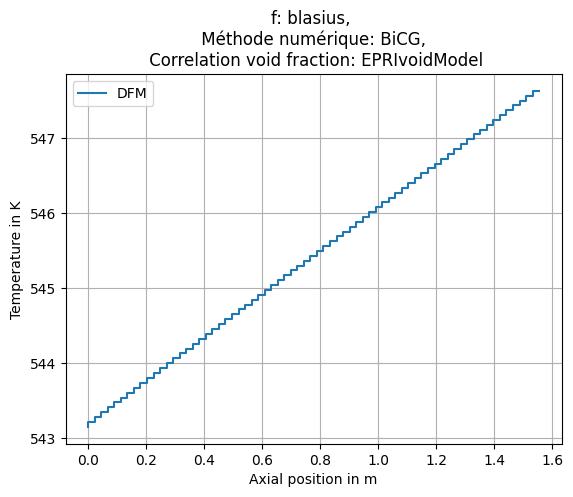

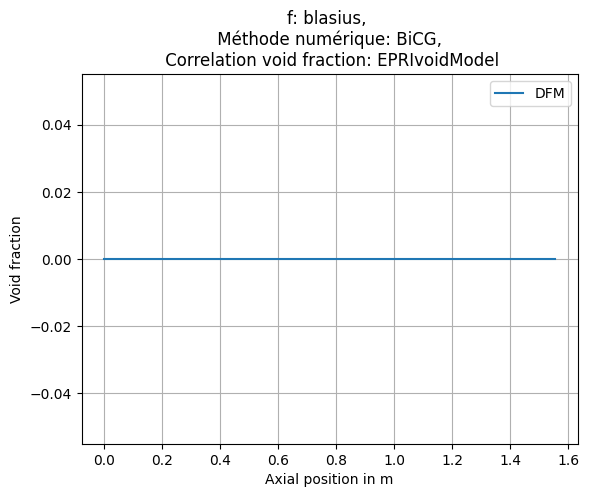

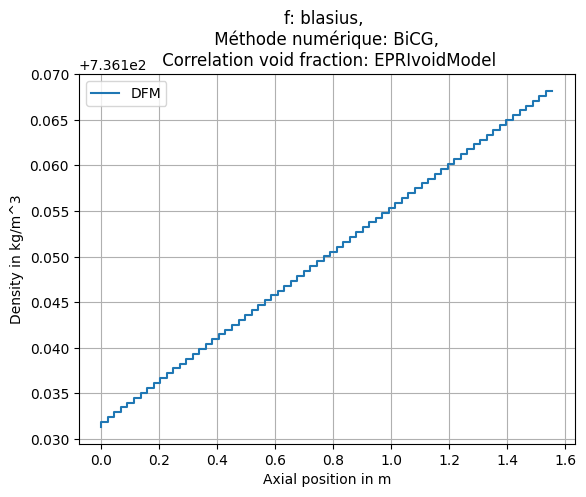

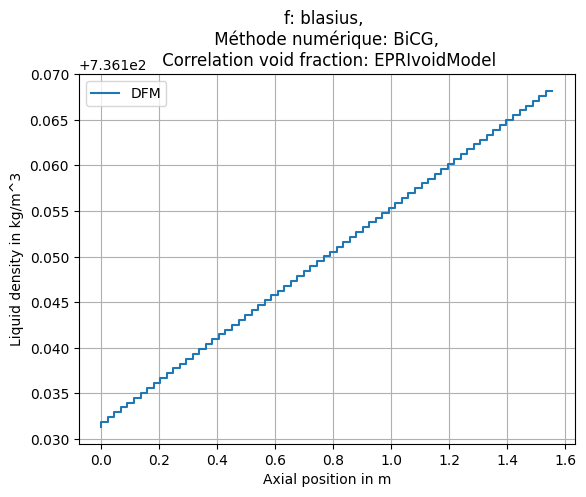

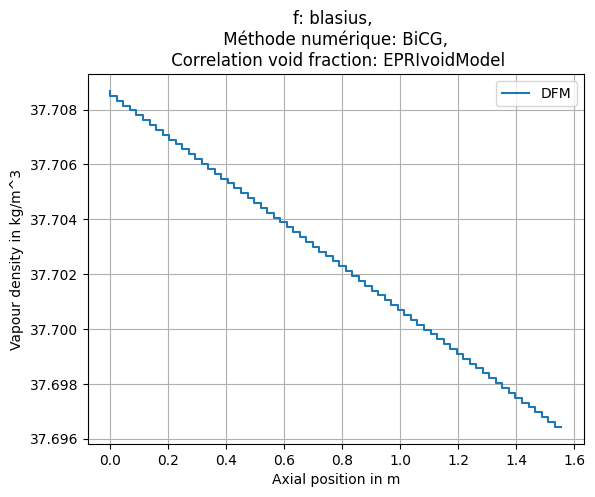

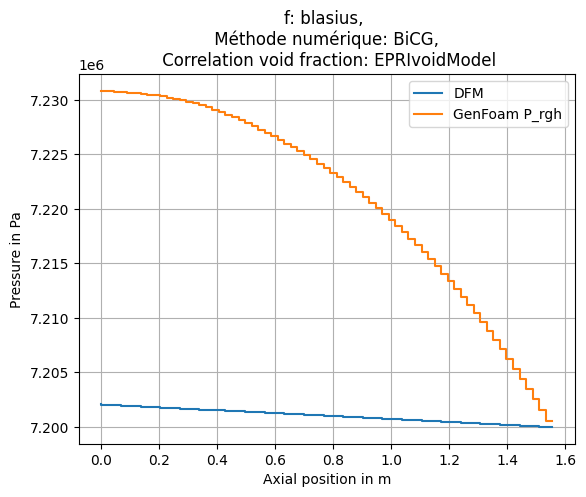

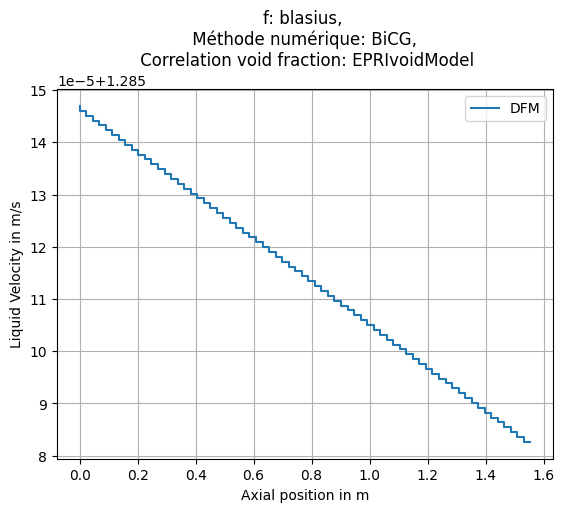

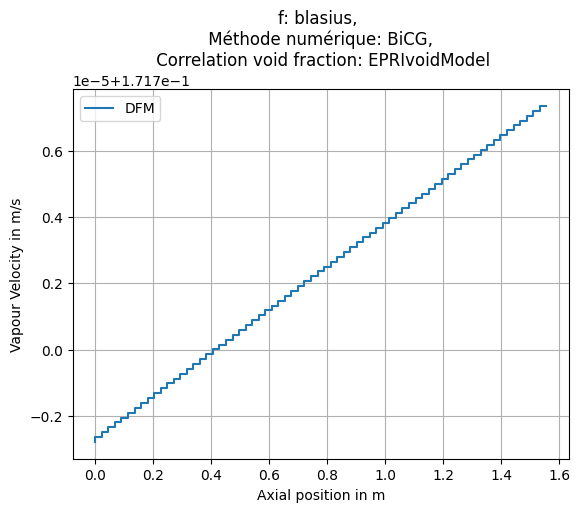

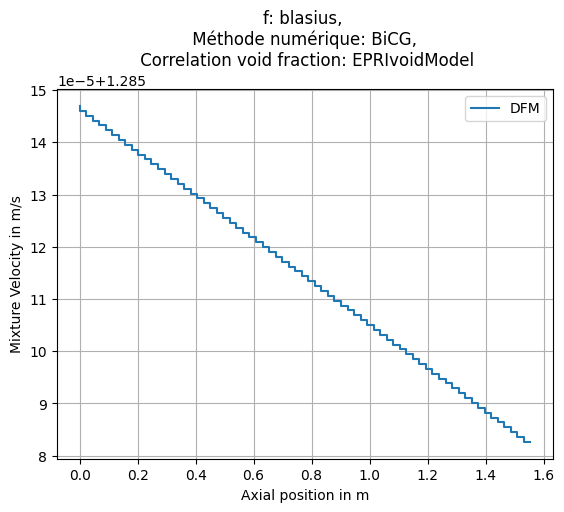

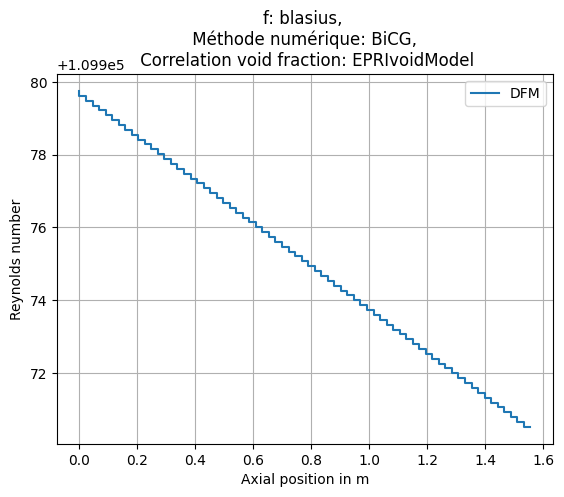

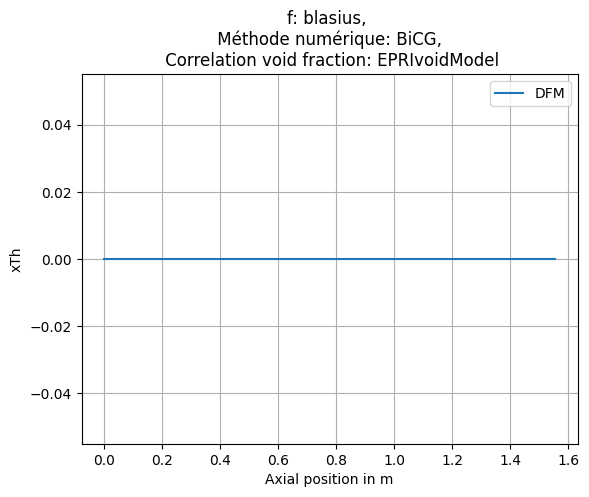

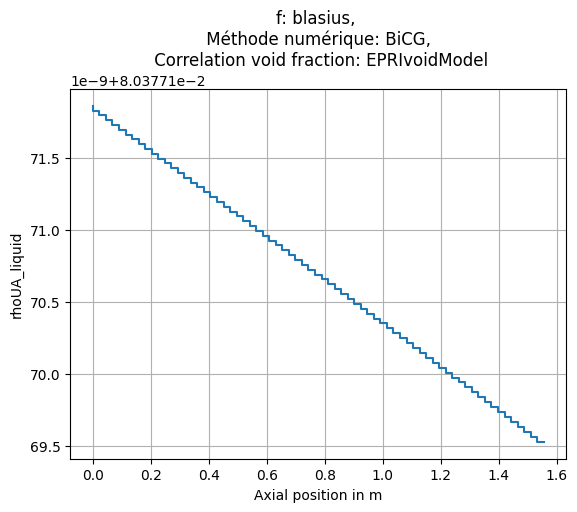

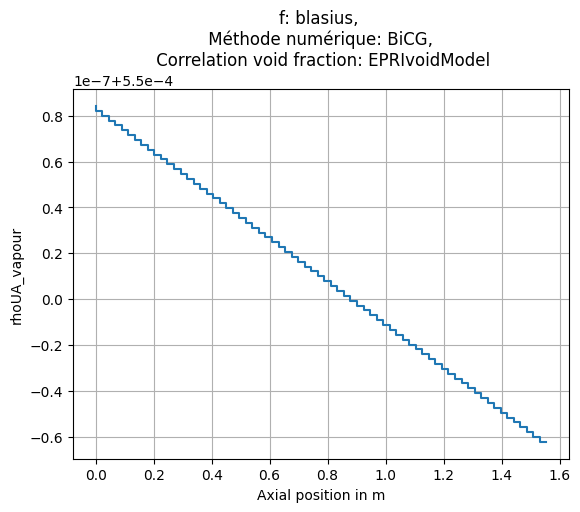

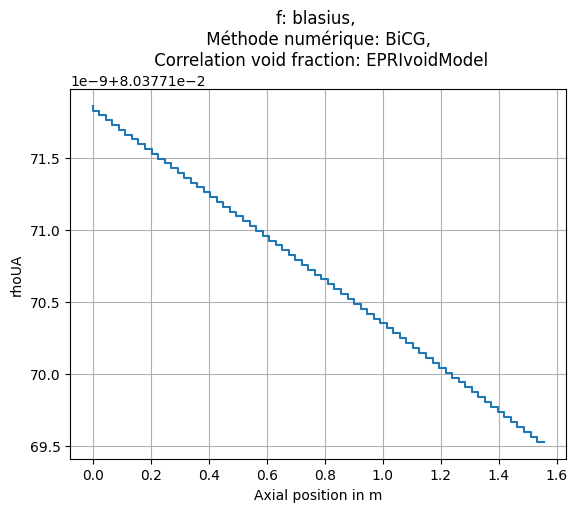

Umixture: [1.28656    1.28806    1.29137286 1.29955282 1.3109404  1.3256576
 1.34372851 1.36550461 1.39146822 1.42222318 1.45844835 1.5008293
 1.55007431 1.60681069 1.67155992 1.7446696  1.82632607 1.9165451
 2.01850533 2.13168995 2.25097377 2.37360772 2.49853898 2.62500369
 2.75214058 2.87960669 3.00730175 3.13518379 3.26318747 3.39128255
 3.51944624 3.64766508 3.77589051 3.90413483 4.03236152 4.16058238
 4.28877238 4.41694436 4.54507851 4.67317771 4.80122471 4.92922036
 5.05715622 5.18501134 5.31279848 5.44051789 5.56817    5.69579771
 5.82340151 5.95096673 6.07851422 6.20603849 6.33352588 6.46097691
 6.58841156 6.71577276 6.84307862 6.97040643 7.09765142 7.22492924
 7.35216505 7.47937433 7.60658384 7.73371393 7.86084173 7.98785206
 8.11485099 8.24164049 8.36906188 8.4897149 ]
zlist Plotter: [0.         0.02253623 0.04507246 0.0676087  0.09014493 0.11268116
 0.13521739 0.15775362 0.18028986 0.20282609 0.22536232 0.24789855
 0.27043478 0.29297101 0.31550725 0.33804348 0.36057971 0.383

In [ ]:
plotter = GFPlotter([case0], rf'C:\Users\cleme\OneDrive\Documents\Poly\BWR\driftFluxModel\thermalHydraulicsPoro\Phase_I\fluidRegion_Qcst', "fluidRegion_Qcst")
#plotter.plotComparison()
plotter.plotCase()
print(f'Umixture: {plotter.U_mixture}')
print(f'zlist Plotter: {plotter.zList}')
print(f'len zListplotter: {len(plotter.zList)}')
print(f'zList convection: {case0.convection_sol.z_mesh}')
print(f'len z list convection {len(case0.convection_sol.z_mesh)}')
print(f'rhoua: {plotter.rhoUA}')  
print(f'rhoL: {case0.convection_sol.rhoL[-1]}')
print(f'rhoG: {case0.convection_sol.rhoG[-1]}')
print(f'rho: {case0.convection_sol.rho[-1]}')


In [ ]:
print(f'volume_fracion_fuel: {(fuelRadius ** 2) / ( cladRadius ** 2)}')
print(f'volume_fracion_clad: {(np.pi *cladRadius ** 2) / waterRadius ** 2}')
q = [flowArea * Qfiss1[i] / (np.pi * fuelRadius ** 2) for i in range(len(Qfiss1))]
print(Qfiss1)
for i in range(len(Qfiss1)):
    print(q[i])

volume_fracion_fuel: 0.7444936713651985
volume_fracion_clad: 0.49415831517907005
[1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301, 1943301]
2671945.3522265987
2671945.3522265987
2671945.3522265987
2671945.3522265987
2671945.3522265987
2671945.3522265987
2671945.3522265987
2671945.3522265987
2671945.3522265987
2671945.3522265987
2671945.3522265987
2671945.3522265987
2671945.3522265987
2671945.3522265987
2671945.3522265987
267